Test the diffusion of single particle on the sphere using the sphere system in III. Spherical System of NERDSS paper SI. One particle can bind to the implicit lipid and diffuse on the sphere

In [52]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt

In [69]:
! rm -r DATA PDB RESTARTS OUTPUT

In [54]:
! ./nerdss -f parms.inp > OUTPUT

In [55]:
import os
from pathlib import Path

In [56]:
import random

random.seed(42)
mols = random.sample(range(1, 10), 9)

In [57]:
PDB_path = "./PDB/"

In [58]:
pdb_files = sorted(
    [f for f in os.listdir(PDB_path) if f.endswith(".pdb")], 
    key=lambda x: int(x.split('.')[0]))

In [59]:
initial_step = int(pdb_files[0].split('.')[0])

In [60]:
initial_step

0

In [61]:
time_range = [0.1, 0.2]
dt = 0.2E-6 #second
step_range_initial = int(time_range[0] / dt) + initial_step
step_range_final = int(time_range[1] / dt) + initial_step

In [62]:
times_list = []
coords = {mol: [] for mol in mols}

In [63]:
for pdb_file in pdb_files:
    step = int(pdb_file.split('.')[0])
    if step_range_initial <= step <= step_range_final:
        times_list.append((step - step_range_initial) * dt)
        
        full_path = Path(PDB_path) / pdb_file
        with open(full_path, "r") as f:
            for line in f.readlines()[2:]:  # Skip header lines
                if line.startswith("ATOM") and "COM" in line:
                    parts = line.split()
                    try:
                        atom_id = int(parts[4])
                        if atom_id in mols:
                            x, y, z = map(float, parts[5:8])
                            coords[atom_id].append([x, y, z])  # Store as list of lists
                    except (IndexError, ValueError):
                        continue

times = np.array(times_list)
for mol in coords:
    coords[mol] = np.array(coords[mol])

In [64]:
print(times[:5])

[0.     0.0002 0.0004 0.0006 0.0008]


In [65]:
max_dt = (time_range[1] - time_range[0]) * 0.8
n_points = len(times)
msd_results = {}

for mol_id, positions in coords.items():
        t_lags = []
        msd_vals = []

        for dt_steps in range(1, n_points):
            dt = times[dt_steps] - times[0]
            if dt > max_dt:
                break

            displacements = []
            for i in range(n_points - dt_steps):
                j = i + dt_steps
                dx, dy = positions[j, 0] - positions[i, 0], positions[j, 1] - positions[i, 1]
                disp_sq = dx**2 + dy**2
                displacements.append(disp_sq)

            if displacements:
                t_lags.append(dt)
                msd_vals.append(np.mean(displacements))

        msd_results[mol_id] = (np.array(t_lags), np.array(msd_vals))

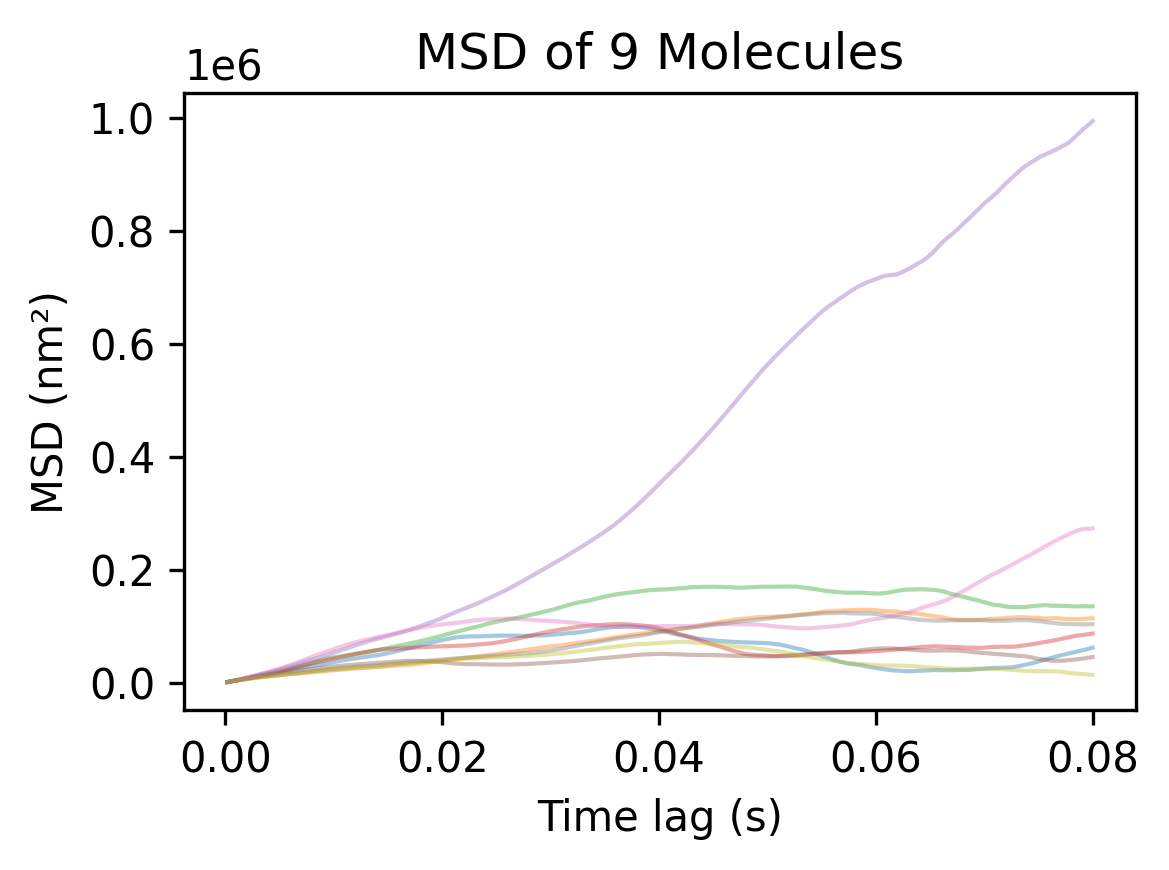

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3), dpi=300)

for mol_id, (t_lags, msd_vals) in msd_results.items():
    plt.plot(t_lags, msd_vals, linewidth=1, alpha=0.4, label=f'Mol {mol_id}')

plt.xlabel("Time lag (s)")
plt.ylabel("MSD (nm²)")
plt.title(f"MSD of {len(mols)} Molecules")
plt.tight_layout()
plt.show()

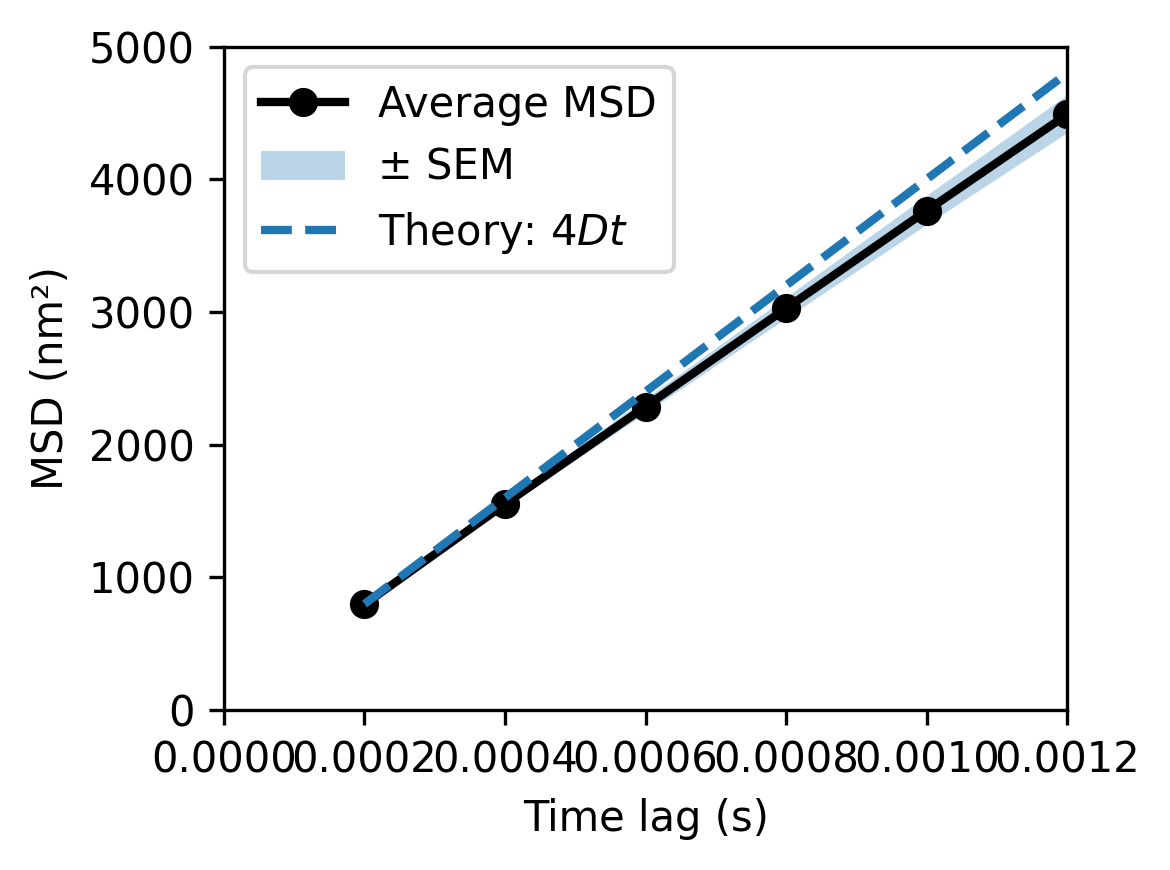

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

msd_by_lag = defaultdict(list)

for t_lags, msd_vals in msd_results.values():
    for t, msd in zip(t_lags, msd_vals):
        msd_by_lag[round(t, 4)].append(msd)

sorted_lags = sorted(msd_by_lag.keys())
avg_msd = []
sem_msd = []

for t in sorted_lags:
    values = msd_by_lag[t]
    if len(values) > 1:  # ensure SEM is meaningful
        avg_msd.append(np.mean(values))
        sem_msd.append(np.std(values) / np.sqrt(len(values)))
    else:
        avg_msd.append(np.nan)
        sem_msd.append(np.nan)

t_array = np.array(sorted_lags)
avg_msd = np.array(avg_msd)
sem_msd = np.array(sem_msd)

D = 1 / (1/2 + 1/2)

# Theoretical MSD line
theory_msd = 4E6 * D * t_array

plt.figure(figsize=(4, 3), dpi=300)
plt.plot(t_array, avg_msd, '-o', label="Average MSD", color='black', linewidth=2)
plt.fill_between(t_array, avg_msd - sem_msd, avg_msd + sem_msd, alpha=0.3, label="± SEM")
plt.plot(t_array, theory_msd, '--', label=r'Theory: $4Dt$', linewidth=2)
plt.xlim((0, 0.0012))
plt.ylim((0, 5000))
plt.xlabel("Time lag (s)")
plt.ylabel("MSD (nm²)")
plt.legend()
plt.tight_layout()
plt.show()

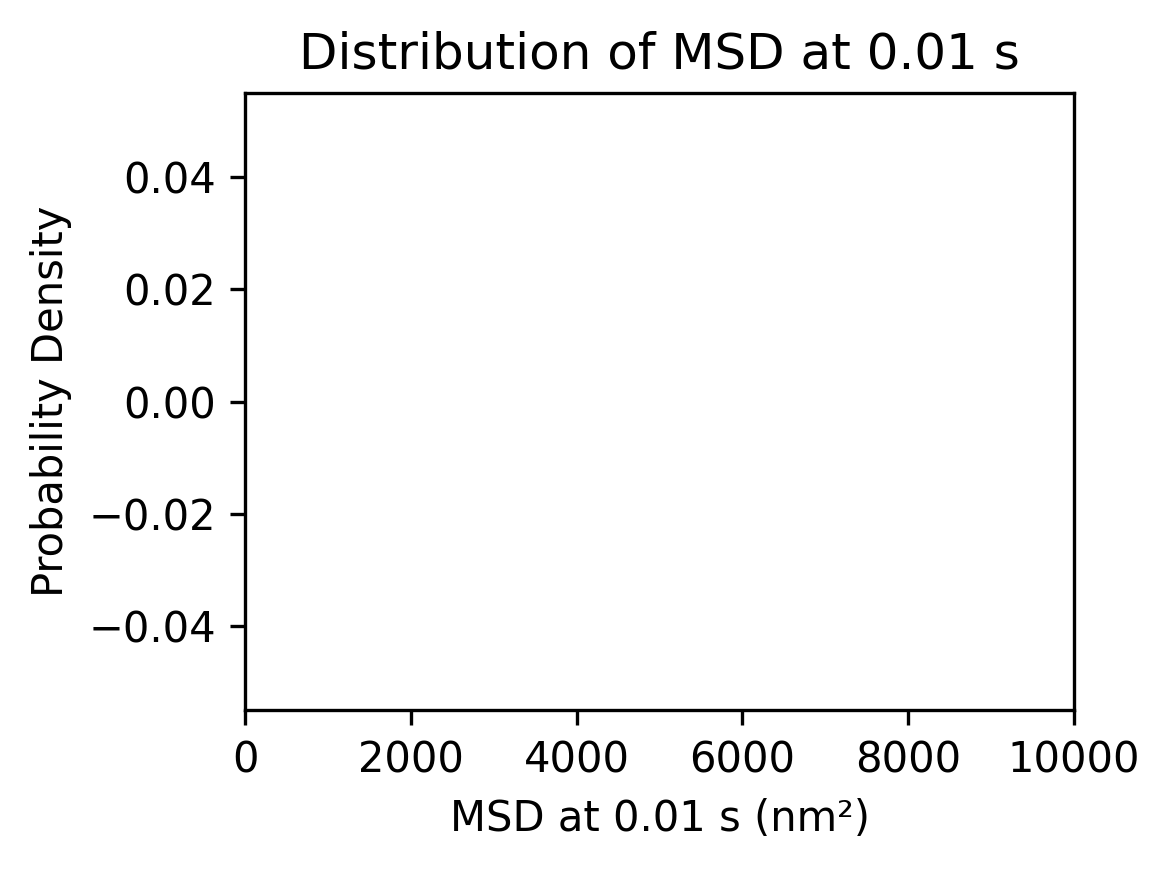

In [68]:
import numpy as np
import matplotlib.pyplot as plt

time_lag_target = 0.01 
tolerance=1e-3 
bins=30
range_min, range_max = 0, 10000

msd_at_lag = []

for t_lags, msd_vals in msd_results.values():
    # Find the closest time lag
    idx = np.argmin(np.abs(t_lags - time_lag_target))
    if abs(t_lags[idx] - time_lag_target) <= tolerance:
        msd_at_lag.append(msd_vals[idx])

if not msd_at_lag:
    print(f"No MSD values found near lag {time_lag_target}s (tolerance={tolerance})")

bin_edges = np.linspace(range_min, range_max, bins + 1)

plt.figure(figsize=(4, 3), dpi=300)
plt.hist(msd_at_lag, bins=bin_edges, alpha=0.7, edgecolor='black', density=True)
plt.xlabel(f"MSD at {time_lag_target:.2f} s (nm²)")
plt.ylabel("Probability Density")
plt.title(f"Distribution of MSD at {time_lag_target:.2f} s")
plt.xlim(range_min, range_max)
plt.tight_layout()
plt.show()